# Predikcija cene polovnih automobila

## 1. Uvod

Cilj projekta je razvoj regresionog sistema koji predviđa **`priceUSD`**, odnosno tržišnu cenu polovnog automobila.

Projekat prati kompletan regresioni workflow:

**EDA → čišćenje → feature engineering → preprocessing → treniranje → evaluacija → poređenje → izbor finalnog modela**

Posebna pažnja je posvećena tome da preprocessing bude deo reproducibilnog workflow-a i da se informacije iz test skupa ne koriste prilikom učenja transformacija.


## 2. Učitavanje biblioteka i podataka

Koristimo `cars.csv` iz direktorijuma `data/`. Notebook je organizovan tako da se većina logike nalazi u Python modulima iz direktorijuma `src/`, dok notebook služi za analizu, vizuelizaciju i prezentaciju rezultata.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

ROOT = Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from data_cleaning import clean_data, cleaning_report
from feature_engineering import add_features
from data_preprocessing import (
    TARGET, NUMERIC_FEATURES, CATEGORICAL_FEATURES,
    split_features_target, build_preprocessor
)
from model_comparison import evaluate_models

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv(ROOT / "data" / "cars.csv")
print("Dimenzije dataset-a:", df.shape)
display(df.head())


Dimenzije dataset-a: (56244, 12)


,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,"162,000.00",petrol,"1,500.00",burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,"120,000.00",petrol,"1,300.00",black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,"61,000.00",petrol,"1,500.00",silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,"265,000.00",diesel,"1,400.00",white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,"97,183.00",diesel,"1,400.00",gray,mechanics,front-wheel drive,B


## 3. Razumevanje skupa podataka

Dataset sadrži karakteristike polovnih automobila. Ciljna promenljiva je `priceUSD`, dok se ostale kolone mogu koristiti kao ulazne karakteristike.

Pre modeliranja proveravamo strukturu, tipove podataka, jedinstvene vrednosti i kvalitet podataka.


In [2]:
structure = pd.DataFrame({
    "kolona": df.columns,
    "tip": df.dtypes.astype(str).values,
    "broj_jedinstvenih": [df[c].nunique(dropna=True) for c in df.columns],
    "missing": [df[c].isna().sum() for c in df.columns],
    "missing_%": [(df[c].isna().mean()*100) for c in df.columns],
})
display(structure)


,kolona,tip,broj_jedinstvenih,missing,missing_%
0,make,object,96,0,0.00
1,model,object,1034,0,0.00
2,priceUSD,int64,2970,0,0.00
3,year,int64,78,0,0.00
4,condition,object,3,0,0.00
5,mileage(kilometers),float64,8400,0,0.00
6,fuel_type,object,3,0,0.00
7,volume(cm3),float64,458,47,0.08
8,color,object,13,0,0.00
9,transmission,object,2,0,0.00


In [3]:
print("Broj redova:", len(df))
print("Broj kolona:", df.shape[1])
print("Broj dupliranih redova:", df.duplicated().sum())

display(df.describe(include="all").T)


Broj redova: 56244
Broj kolona: 12
Broj dupliranih redova: 87


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
make,56244,96,volkswagen,6861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,56244,1034,passat,2086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priceUSD,"56,244.00",NaN,NaN,NaN,"7,415.46","8,316.96",48.00,"2,350.00","5,350.00","9,807.50","235,235.00"
year,"56,244.00",NaN,NaN,NaN,"2,003.45",8.14,"1,910.00","1,998.00","2,004.00","2,010.00","2,019.00"
condition,56244,3,with mileage,55278,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage(kilometers),"56,244.00",NaN,NaN,NaN,"244,395.63","321,030.67",0.00,"137,000.00","228,500.00","310,000.00","9,999,999.00"
fuel_type,56244,3,petrol,36405,NaN,NaN,NaN,NaN,NaN,NaN,NaN
volume(cm3),"56,197.00",NaN,NaN,NaN,"2,104.86",959.20,500.00,"1,600.00","1,996.00","2,300.00","20,000.00"
color,56244,13,black,12385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,56244,2,mechanics,36056,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Analiza nedostajućih vrednosti

Nedostajuće vrednosti su prisutne u pojedinim kolonama, naročito u `segment`, `drive_unit` i `volume(cm3)`.

Nećemo ih proizvoljno brisati. Za numeričke karakteristike koristićemo medijanu, a za kategorijske najčešću vrednost kroz `SimpleImputer` u preprocessing pipeline-u.


In [4]:
missing = (
    df.isna().sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(2)
display(missing[missing["missing_count"] > 0])


,missing_count,missing_percent
segment,5291,9.41
drive_unit,1905,3.39
volume(cm3),47,0.08


## 5. Ciljna promenljiva – `priceUSD`

Cena je numerička ciljna promenljiva. Pre modeliranja proveravamo njen raspon, centralnu tendenciju i raspodelu.

Kod realnih cena ekstremno skupi automobili ne moraju biti greška, zato ekstremne vrednosti razlikujemo od očigledno nevalidnih vrednosti.


,priceUSD
count,"56,244.00"
mean,"7,415.46"
std,"8,316.96"
min,48.00
25%,"2,350.00"
50%,"5,350.00"
75%,"9,807.50"
max,"235,235.00"


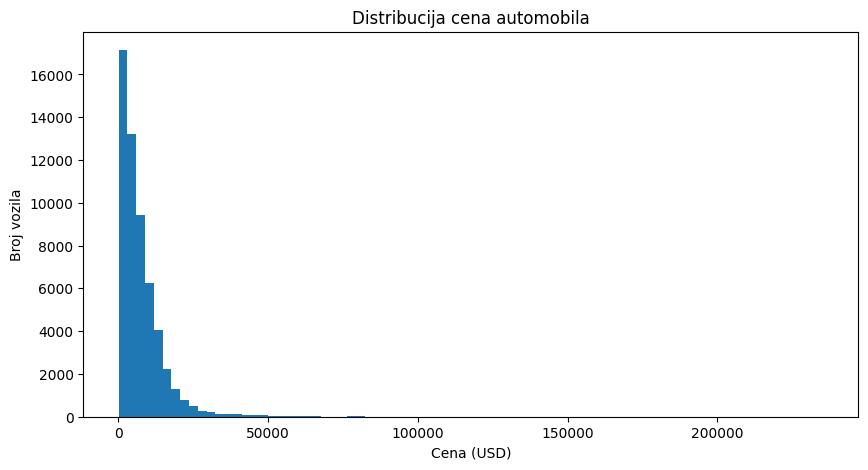

In [5]:
price_stats = df["priceUSD"].describe()
display(price_stats.to_frame("priceUSD"))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["priceUSD"], bins=80)
ax.set_title("Distribucija cena automobila")
ax.set_xlabel("Cena (USD)")
ax.set_ylabel("Broj vozila")
plt.show()


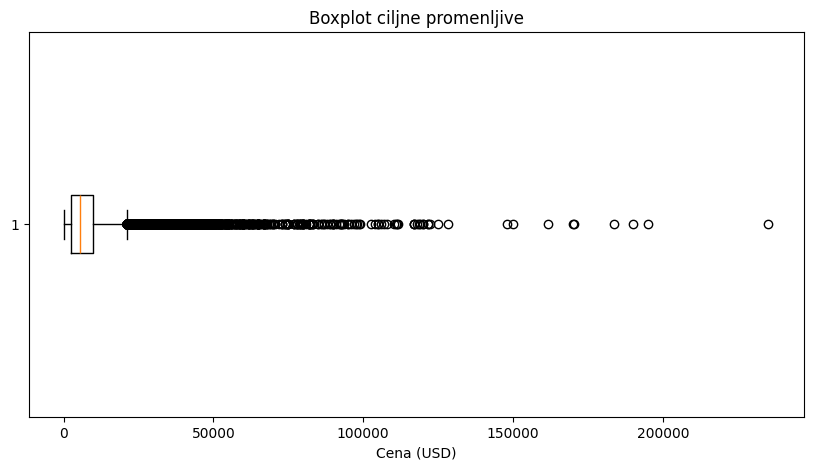

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(df["priceUSD"], vert=False)
ax.set_title("Boxplot ciljne promenljive")
ax.set_xlabel("Cena (USD)")
plt.show()


## 6. Numeričke karakteristike i odnosi sa cenom

Posmatramo numeričke karakteristike i njihove odnose sa ciljem. Korelacija je samo pomoćni signal; ona ne dokazuje uzročnost i ne može sama odlučiti koji model je najbolji.


In [7]:
numeric_raw = df.select_dtypes(include=np.number).columns.tolist()
print("Numeričke kolone:", numeric_raw)

corr = df[numeric_raw].corr(numeric_only=True)["priceUSD"].sort_values(ascending=False)
display(corr.to_frame("korelacija_sa_cenom"))


Numeričke kolone: ['priceUSD', 'year', 'mileage(kilometers)', 'volume(cm3)']


,korelacija_sa_cenom
priceUSD,1.00
year,0.61
volume(cm3),0.27
mileage(kilometers),-0.17


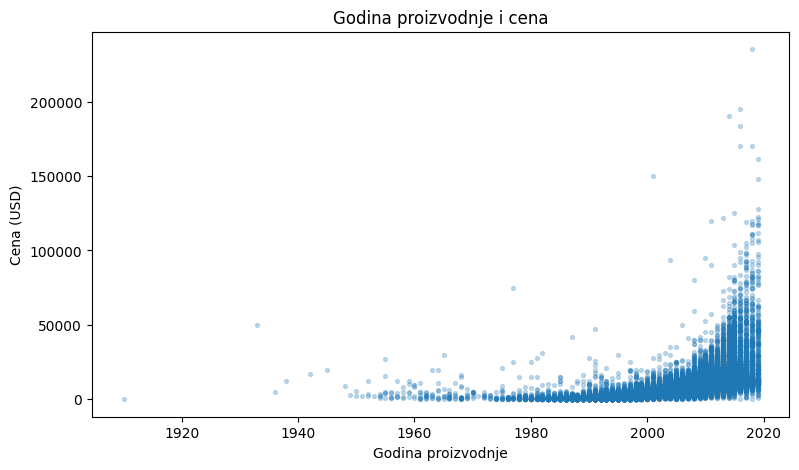

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df["year"], df["priceUSD"], s=8, alpha=0.25)
ax.set_title("Godina proizvodnje i cena")
ax.set_xlabel("Godina proizvodnje")
ax.set_ylabel("Cena (USD)")
plt.show()


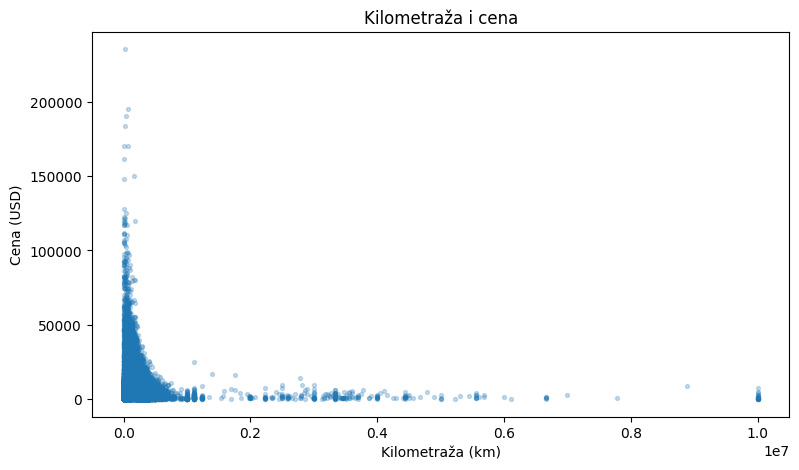

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df["mileage(kilometers)"], df["priceUSD"], s=8, alpha=0.25)
ax.set_title("Kilometraža i cena")
ax.set_xlabel("Kilometraža (km)")
ax.set_ylabel("Cena (USD)")
plt.show()


## 7. Analiza kategorijskih karakteristika

Kategorijske promenljive mogu imati veliki broj kategorija. `model` i izvedeni `brand_model` su posebno detaljni, zbog čega koristimo `OneHotEncoder(handle_unknown="ignore")`.

Kod novih podataka kategorija koju model nije video tokom treninga neće izazvati grešku.


In [10]:
categorical_raw = df.select_dtypes(include="object").columns.tolist()

for col in categorical_raw:
    print(f"{col}: {df[col].nunique(dropna=True)} jedinstvenih vrednosti")

print("\nNajčešće marke:")
display(df["make"].value_counts().head(15).to_frame("broj"))

print("\nStanje vozila:")
display(df["condition"].value_counts(dropna=False).to_frame("broj"))


make: 96 jedinstvenih vrednosti
model: 1034 jedinstvenih vrednosti
condition: 3 jedinstvenih vrednosti
fuel_type: 3 jedinstvenih vrednosti
color: 13 jedinstvenih vrednosti
transmission: 2 jedinstvenih vrednosti
drive_unit: 4 jedinstvenih vrednosti
segment: 9 jedinstvenih vrednosti

Najčešće marke:


,broj
make,
volkswagen,6861
audi,4030
bmw,4013
opel,3779
renault,3713
mercedes-benz,3541
ford,3078
peugeot,2876
nissan,2233



Stanje vozila:


,broj
condition,
with mileage,55278
with damage,512
for parts,454


## 8. Identifikacija potencijalno nevalidnih vrednosti

Pre čišćenja proveravamo fizički i poslovno nelogične vrednosti:

- godina pre 1950;
- kilometraža iznad 1.500.000 km;
- zapremina motora iznad 10.000 cm³;
- cena ispod 100 USD.

Ove granice nisu zamena za domensko znanje, već konzervativna pravila za uklanjanje očigledno problematičnih zapisa.


In [11]:
checks = pd.DataFrame({
    "problem": [
        "priceUSD < 100",
        "year < 1950",
        "mileage(kilometers) > 1,500,000",
        "volume(cm3) > 10,000",
    ],
    "broj_redova": [
        (df["priceUSD"] < 100).sum(),
        (df["year"] < 1950).sum(),
        (df["mileage(kilometers)"] > 1_500_000).sum(),
        (df["volume(cm3)"] > 10_000).sum(),
    ]
})
display(checks)


,problem,broj_redova
0,priceUSD < 100,2
1,year < 1950,8
2,"mileage(kilometers) > 1,500,000",252
3,"volume(cm3) > 10,000",86


## 9. Čišćenje podataka

Čišćenje se izvršava funkcijom `clean_data()` iz `src/data_cleaning.py`.

Važno: missing values ostaju prisutne nakon čišćenja kada predstavljaju stvarno nedostajući podatak. Njih će kasnije obraditi pipeline.


In [12]:
clean_df = clean_data(df)
report = cleaning_report(df, clean_df)

print(f"Redova pre čišćenja: {len(df):,}")
print(f"Redova posle čišćenja: {len(clean_df):,}")
print(f"Uklonjeno: {len(df)-len(clean_df):,}")

display(report)


Redova pre čišćenja: 56,244
Redova posle čišćenja: 55,812
Uklonjeno: 432


,check,raw,cleaned
0,rows,56244,55812
1,duplicates,87,0
2,missing_volume,47,47
3,missing_drive_unit,1905,1886
4,missing_segment,5291,5256


In [13]:
print("Provera posle čišćenja:")
print("Min cena:", clean_df["priceUSD"].min())
print("Min godina:", clean_df["year"].min())
print("Max godina:", clean_df["year"].max())
print("Max kilometraža:", clean_df["mileage(kilometers)"].max())
print("Max zapremina:", clean_df["volume(cm3)"].max())


Provera posle čišćenja:
Min cena: 100
Min godina: 1950
Max godina: 2019
Max kilometraža: 1400000.0
Max zapremina: 10000.0


## 10. Feature engineering

Pored originalnih kolona kreiramo karakteristike koje imaju jasnu interpretaciju:

- `car_age` – starost automobila u odnosu na 2019;
- `mileage_per_year` – prosečna kilometraža po godini;
- `engine_volume_liters` – zapremina u litrima;
- `is_newer_car` – indikator novijeg automobila;
- `is_high_mileage` – indikator velike kilometraže;
- `brand_model` – kombinacija marke i modela;
- log transformacije i nelinearni termini za bogatiji opis odnosa.


In [14]:
features_df = add_features(clean_df)

engineered = [
    "car_age", "mileage_per_year", "engine_volume_liters",
    "is_newer_car", "is_high_mileage", "brand_model",
    "log_mileage", "log_engine_volume", "age_squared",
    "mileage_age_interaction"
]
display(features_df[engineered].head())


,car_age,mileage_per_year,engine_volume_liters,is_newer_car,is_high_mileage,brand_model,log_mileage,log_engine_volume,age_squared,mileage_age_interaction
0,11,"14,727.27",1.50,0,0,mazda_2,12.00,7.31,121,"1,782,000.00"
1,10,"12,000.00",1.30,0,0,mazda_2,11.70,7.17,100,"1,200,000.00"
2,10,"6,100.00",1.50,0,0,mazda_2,11.02,7.31,100,"610,000.00"
3,16,"16,562.50",1.40,0,0,mazda_2,12.49,7.24,256,"4,240,000.00"
4,11,"8,834.82",1.40,0,0,mazda_2,11.48,7.24,121,"1,069,013.00"


In [15]:
display(features_df[engineered].describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_age,"55,812.00",NaN,NaN,NaN,15.49,8.09,0.00,9.00,15.00,21.00,69.00
mileage_per_year,"55,812.00",NaN,NaN,NaN,"17,141.34","10,060.28",0.00,"12,000.00","16,181.82","21,052.63","330,000.00"
engine_volume_liters,"55,765.00",NaN,NaN,NaN,2.08,0.72,0.50,1.60,2.00,2.30,10.00
is_newer_car,"55,812.00",NaN,NaN,NaN,0.09,0.28,0.00,0.00,0.00,0.00,1.00
is_high_mileage,"55,812.00",NaN,NaN,NaN,0.30,0.46,0.00,0.00,0.00,1.00,1.00
brand_model,55812,1071,volkswagen_passat,2069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
log_mileage,"55,812.00",NaN,NaN,NaN,11.83,1.83,0.00,11.82,12.33,12.63,14.15
log_engine_volume,"55,765.00",NaN,NaN,NaN,7.59,0.30,6.22,7.38,7.60,7.74,9.21
age_squared,"55,812.00",NaN,NaN,NaN,305.41,306.57,0.00,81.00,225.00,441.00,"4,761.00"
mileage_age_interaction,"55,812.00",NaN,NaN,NaN,"3,975,933.36","3,629,078.53",0.00,"1,116,000.00","3,200,000.00","6,000,000.00","63,333,327.00"


## 11. Provera distribucije novih karakteristika

Feature engineering ne znači samo dodavanje kolona. Potrebno je proveriti da nove promenljive imaju smislene vrednosti i da nema novih nelogičnosti.


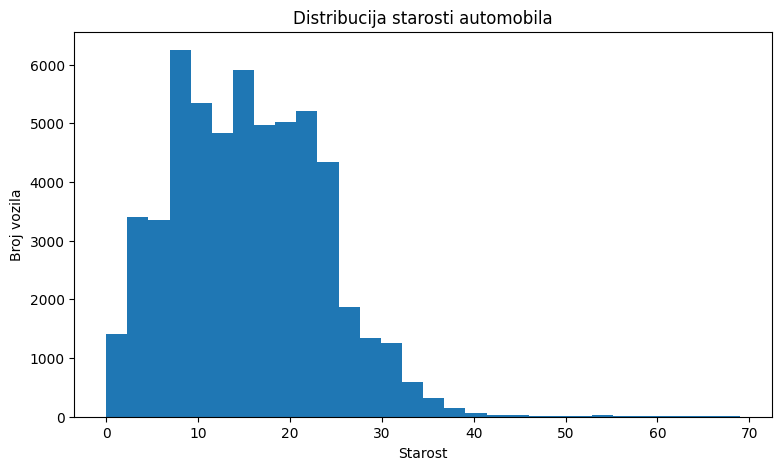

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(features_df["car_age"], bins=30)
ax.set_title("Distribucija starosti automobila")
ax.set_xlabel("Starost")
ax.set_ylabel("Broj vozila")
plt.show()


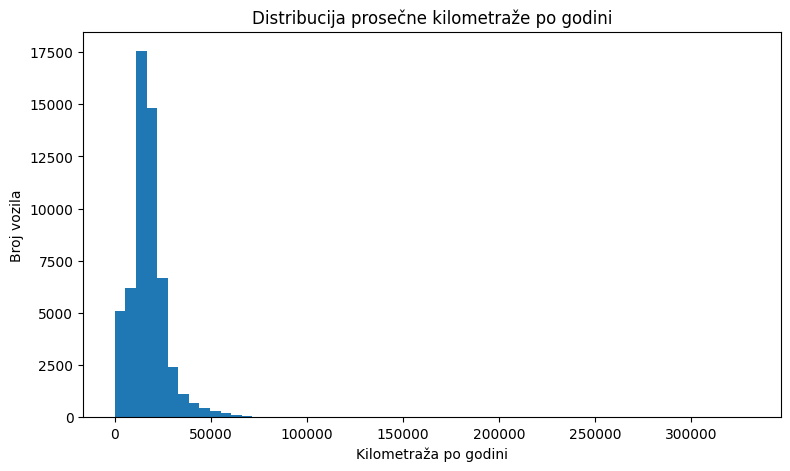

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(features_df["mileage_per_year"], bins=60)
ax.set_title("Distribucija prosečne kilometraže po godini")
ax.set_xlabel("Kilometraža po godini")
ax.set_ylabel("Broj vozila")
plt.show()


## 12. Definisanje `X` i `y`

Target je `priceUSD`. Sve ostale odabrane karakteristike predstavljaju ulaz u model.

Numeričke i kategorijske kolone eksplicitno definišemo kako bi preprocessing bio reproducibilan.


In [18]:
X, y = split_features_target(features_df)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nNumeričke karakteristike:")
print(NUMERIC_FEATURES)
print("\nKategorijske karakteristike:")
print(CATEGORICAL_FEATURES)


X shape: (55812, 21)
y shape: (55812,)

Numeričke karakteristike:
['year', 'mileage(kilometers)', 'volume(cm3)', 'car_age', 'mileage_per_year', 'engine_volume_liters', 'is_newer_car', 'is_high_mileage', 'log_mileage', 'log_engine_volume', 'age_squared', 'mileage_age_interaction']

Kategorijske karakteristike:
['make', 'model', 'condition', 'fuel_type', 'color', 'transmission', 'drive_unit', 'segment', 'brand_model']


## 13. Train/Test podela i sprečavanje data leakage-a

Koristimo 80% podataka za trening i 20% za testiranje.

Preprocessor se fituje **isključivo na trening skupu**. Tek nakon toga se transformiše test skup. Na ovaj način statistike imputacije, skaliranja i kategorije encoder-a ne koriste test podatke tokom učenja.


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (44649, 21)
Test : (11163, 21)


## 14. Preprocessing pipeline

Za numeričke kolone koristimo:

1. `SimpleImputer(strategy="median")`
2. `StandardScaler`

Za kategorijske:

1. `SimpleImputer(strategy="most_frequent")`
2. `OneHotEncoder(handle_unknown="ignore")`

Ovakva organizacija omogućava da se isti preprocessing primeni na trening, test i buduće podatke.


In [20]:
preprocessor = build_preprocessor()

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Transformisana train matrica:", X_train_transformed.shape)
print("Transformisana test matrica :", X_test_transformed.shape)


Transformisana train matrica: (44649, 2183)
Transformisana test matrica : (11163, 2183)


## 15. Treniranje i poređenje regresionih modela

Poredićemo najmanje tri različita algoritma:

- **Ridge Regression** – linearni baseline sa L2 regularizacijom;
- **Decision Tree Regressor** – nelinearni model zasnovan na grananju;
- **Random Forest Regressor** – ansambl više stabala.

Svi modeli koriste isti train/test split i isti preprocessing, pa je poređenje konzistentno.


In [21]:
comparison_results, splits, predictions = evaluate_models(df)

display(comparison_results.round(2))


,model,MAE,MSE,RMSE,R2
0,Random Forest,"1,140.02","9,194,379.84","3,032.22",0.87
1,Decision Tree,"1,355.24","12,168,658.09","3,488.36",0.83
2,Ridge Regression,"1,877.55","17,091,859.65","4,134.23",0.76


## 16. Tumačenje metrika

Koristimo četiri metrike:

- **MAE** – prosečno apsolutno odstupanje u USD; manje je bolje;
- **MSE** – prosečna kvadratna greška; manje je bolje;
- **RMSE** – koren MSE-a, izražen u USD; manje je bolje;
- **R²** – deo varijacije cilja koji model objašnjava; veće je bolje.

Za poslovnu interpretaciju MAE je naročito koristan jer je direktno izražen u dolarima.


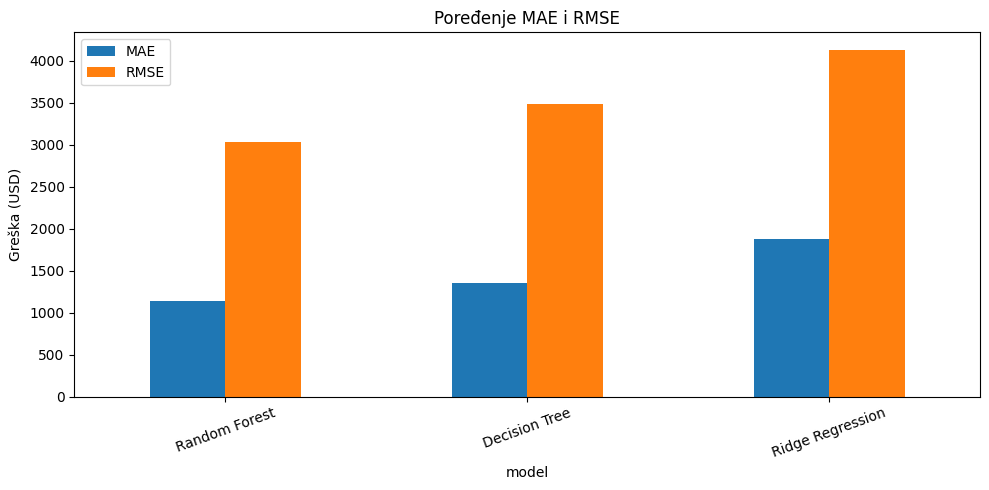

In [22]:
metrics_plot = comparison_results.set_index("model")[["MAE", "RMSE"]]

ax = metrics_plot.plot(kind="bar", figsize=(10, 5))
ax.set_title("Poređenje MAE i RMSE")
ax.set_ylabel("Greška (USD)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## 17. Izbor finalnog modela

Finalni model biramo prvenstveno prema MAE, uz proveru RMSE i R².

Model sa najmanjim prosečnim apsolutnim odstupanjem predstavlja najpraktičniji izbor ako nam je cilj da prosečna greška cene bude što manja.


In [23]:
best_row = comparison_results.iloc[0]

print("Najbolji model prema MAE:", best_row["model"])
print(f"MAE : {best_row['MAE']:,.2f} USD")
print(f"RMSE: {best_row['RMSE']:,.2f} USD")
print(f"R²  : {best_row['R2']:.4f}")


Najbolji model prema MAE: Random Forest
MAE : 1,140.02 USD
RMSE: 3,032.22 USD
R²  : 0.8727


## 18. Detaljna analiza grešaka

Agregatne metrike nisu dovoljne. Posmatramo pojedinačna predviđanja i apsolutne greške da bismo videli kako model funkcioniše na konkretnim automobilima.


In [24]:
best_name = best_row["model"]
best_predictions = predictions[best_name]

_, _, _, y_test_eval = splits
examples = pd.DataFrame({
    "stvarna_cena": y_test_eval.values,
    "predvidjena_cena": best_predictions
})
examples["greska"] = examples["stvarna_cena"] - examples["predvidjena_cena"]
examples["apsolutna_greska"] = examples["greska"].abs()

display(examples.head(15).round(2))


,stvarna_cena,predvidjena_cena,greska,apsolutna_greska
0,2000,"3,488.01","-1,488.01","1,488.01"
1,8033,"8,066.74",-33.74,33.74
2,2500,"2,528.50",-28.50,28.50
3,951,983.74,-32.74,32.74
4,9400,"9,405.91",-5.91,5.91
5,8990,"9,435.62",-445.62,445.62
6,1850,"2,133.09",-283.09,283.09
7,5150,"5,593.08",-443.08,443.08
8,2600,"2,965.89",-365.89,365.89
9,2000,"1,986.66",13.34,13.34


In [25]:
print("Najveće apsolutne greške:")
display(
    examples.sort_values("apsolutna_greska", ascending=False)
            .head(10)
            .round(2)
)


Najveće apsolutne greške:


,stvarna_cena,predvidjena_cena,greska,apsolutna_greska
9132,190141,"65,804.58","124,336.42","124,336.42"
9775,170000,"84,631.45","85,368.55","85,368.55"
6996,93595,"16,561.35","77,033.65","77,033.65"
6730,13000,"72,817.72","-59,817.72","59,817.72"
10474,148000,"88,725.41","59,274.59","59,274.59"
1537,9579,"68,497.31","-58,918.31","58,918.31"
3180,125000,"68,917.36","56,082.64","56,082.64"
5087,99000,"52,058.46","46,941.54","46,941.54"
7758,108000,"65,609.97","42,390.03","42,390.03"
8046,2500,"40,977.91","-38,477.91","38,477.91"


## 19. Actual vs. Predicted

Idealno bi sva predviđanja ležala blizu dijagonale `y = x`. Veće udaljavanje od dijagonale ukazuje na veće greške.


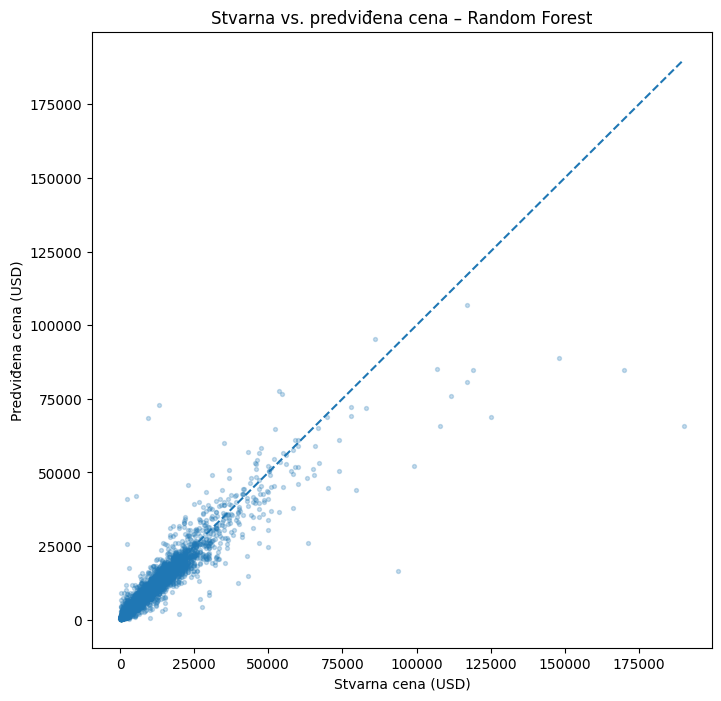

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(examples["stvarna_cena"], examples["predvidjena_cena"], s=8, alpha=0.25)

limit = max(examples["stvarna_cena"].max(), examples["predvidjena_cena"].max())
ax.plot([0, limit], [0, limit], linestyle="--")

ax.set_title(f"Stvarna vs. predviđena cena – {best_name}")
ax.set_xlabel("Stvarna cena (USD)")
ax.set_ylabel("Predviđena cena (USD)")
plt.show()


## 20. Distribucija grešaka

Analiziramo reziduale, odnosno razliku između stvarne i predviđene cene.


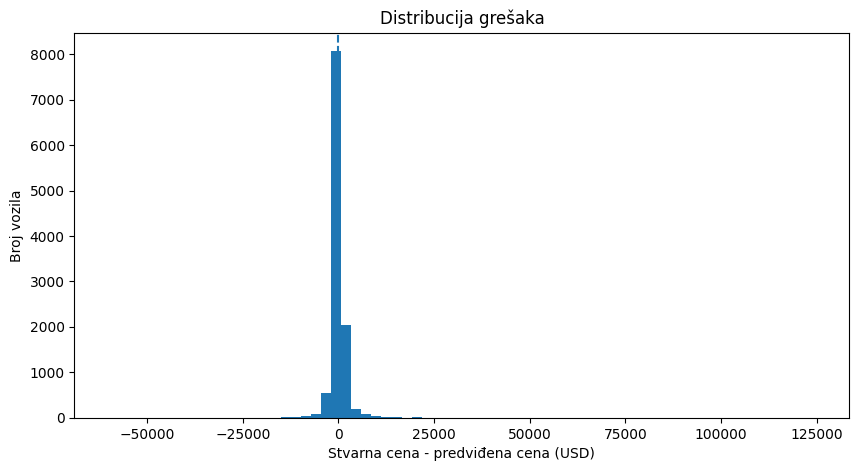

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(examples["greska"], bins=70)
ax.axvline(0, linestyle="--")
ax.set_title("Distribucija grešaka")
ax.set_xlabel("Stvarna cena - predviđena cena (USD)")
ax.set_ylabel("Broj vozila")
plt.show()


## 21. Feature importance finalnog Random Forest modela

Kod stabla/ansambla možemo analizirati relativni značaj transformisanih karakteristika.

Napomena: importance nije isto što i uzročni uticaj. Ona samo pokazuje koliko je karakteristika korišćena u strukturi modela za smanjenje greške.


In [28]:
final_model = joblib.load(ROOT / "models" / "car_price_model.joblib")

model_step = final_model.named_steps["model"]
prep_step = final_model.named_steps["preprocessor"]

feature_names = prep_step.get_feature_names_out()
importance = pd.Series(model_step.feature_importances_, index=feature_names)
importance = importance.sort_values(ascending=False).head(20)

display(importance.to_frame("importance"))


,importance
numeric__car_age,0.22
numeric__age_squared,0.17
numeric__year,0.14
numeric__engine_volume_liters,0.10
numeric__volume(cm3),0.08
numeric__log_engine_volume,0.06
numeric__is_newer_car,0.03
categorical__make_bentley,0.02
numeric__mileage_age_interaction,0.02
categorical__drive_unit_all-wheel drive,0.01


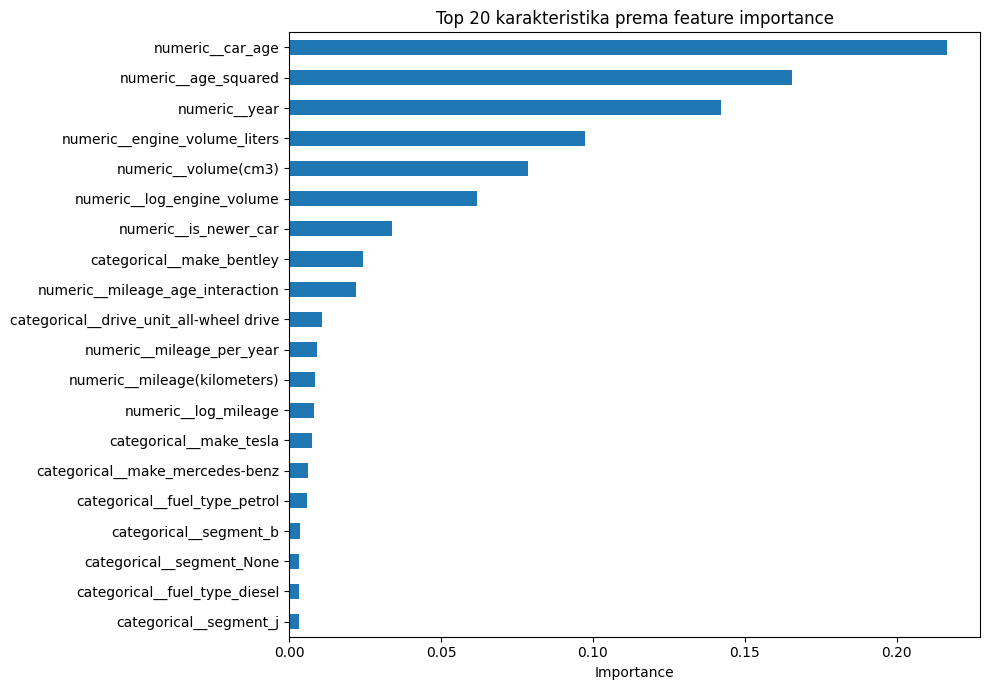

In [29]:
fig, ax = plt.subplots(figsize=(10, 7))
importance.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 karakteristika prema feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


## 22. Finalni model i rezultat

Finalni model je sačuvan u `models/car_price_model.joblib`.

Na test skupu prikazujemo konačne metrike. Model treba tumačiti kao alat za procenu tržišne cene, a ne kao garanciju da će svaki oglas biti pogođen sa istom preciznošću.


In [30]:
final_metrics = pd.read_csv(ROOT / "reports" / "final_metrics.csv")
display(final_metrics.round(4))

print("Finalni model:", best_name)
print(f"MAE ≈ {final_metrics.loc[0, 'MAE']:,.2f} USD")
print(f"RMSE ≈ {final_metrics.loc[0, 'RMSE']:,.2f} USD")
print(f"R² ≈ {final_metrics.loc[0, 'R2']:.4f}")


,MAE,MSE,RMSE,R2
0,"1,140.02","9,194,379.84","3,032.22",0.87


Finalni model: Random Forest
MAE ≈ 1,140.02 USD
RMSE ≈ 3,032.22 USD
R² ≈ 0.8727


## 23. Zaključak

U ovom projektu je implementiran kompletan regresioni workflow za predviđanje cene polovnih automobila.

Najvažniji koraci:

- dataset je istražen kroz EDA;
- identifikovane su nedostajuće i potencijalno nevalidne vrednosti;
- sprovedeno je čišćenje podataka;
- kreirane su dodatne karakteristike;
- numeričke i kategorijske promenljive pripremljene su kroz pipeline;
- upoređena su najmanje tri regresiona algoritma;
- rezultati su procenjeni pomoću MAE, MSE, RMSE i R²;
- finalni model je sačuvan kao `.joblib`.

Na osnovu rezultata izabran je model sa najboljim rezultatima na izdvojenom test skupu.
